In [68]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import random
import time
import torch
import torch.nn.functional as F
from tqdm import tqdm
from torch import nn

In [69]:
from typing import Any


class AbstracMultiLoraModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(10, 10)
        self.linear = nn.Linear(10, 10)
        self.lm_head = nn.Linear(10, 10)

    def linear_lora(
        self,
        x: torch.Tensor,                 # [batch_size, seq_len, in_features]
        loras_a: torch.Tensor,           # [num_loras, in_features, rank]
        loras_b: torch.Tensor,           # [num_loras, rank, in_features]
        lora_indices: torch.LongTensor,  # [batch_size]
    ) -> torch.Tensor:
        raise NotImplementedError()

    def forward(self, input_ids, loras_a, loras_b, lora_indices):
        x = self.embedding(input_ids)
        x = self.linear_lora(x, loras_a, loras_b, lora_indices)
        x= self.lm_head(x)
        return x

In [70]:
class LoopMultiLoraModel(AbstracMultiLoraModel):
    def linear_lora(
        self,
        x: torch.Tensor,                 # [batch_size, seq_len, in_features]
        loras_a: torch.Tensor,           # [num_loras, in_features, rank]
        loras_b: torch.Tensor,           # [num_loras, rank, in_features]
        lora_indices: torch.LongTensor,  # [batch_size]
    ) -> torch.Tensor:
        y = self.linear(x)
        for batch_idx, lora_idx in enumerate(lora_indices.numpy()):
            lora_a = loras_a[lora_idx]
            lora_b = loras_b[lora_idx]
            y[batch_idx] = x[batch_idx] @ lora_a @ lora_b
        return y

In [71]:
# toy example of a detokenizer. The vocabular only consists of 10 words (different colors)
detokenizer = [
    "red",
    "orange",
    "yellow",
    "green",
    "blue",
    "indigo",
    "violet",
    "magenta",
    "marigold",
    "chartreuse",
]

In [72]:
# dummy inputs
input_ids = torch.LongTensor([[0, 1, 2, 3, 4, 5, 6, 7]])

In [73]:
torch.manual_seed(42)

In [74]:
def generate_token(model, **kw):
    with torch.no_grad():
        logits = model(**kw)
        last_logits = logits[:, -1, :]
        next_token_ids = last_logits.argmax(dim=1)

    return [detokenizer[token_id] for token_id in next_token_ids]
    

In [84]:
model = LoopMultiLoraModel()

In [76]:
# constants
bs = 1
num_loras = 64
h = 10
r = 2

loras_a = torch.randn(num_loras, h, r)
loras_b = torch.randn(num_loras, r, h)

for i in range(10):
    lora_indices = torch.randint(num_loras, (bs, ), dtype=torch.long)
    next_token = generate_token(
        model,
        input_ids = input_ids,
        loras_a = loras_a,
        loras_b = loras_b,
        lora_indices = lora_indices
    )
    print(next_token)

['orange']
['yellow']
['chartreuse']
['yellow']
['marigold']
['yellow']
['red']
['orange']
['violet']
['chartreuse']


In [ ]:
# constants
seq_len = 8
vocab_size = 10
nsamples = 500
max_batch_size = 64

def benchmark(model):
    avg_latencies = []
    for bs in range(1, max_batch_size + 1):
        latencies = []
        for _ in range(nsamples):
            input_ids = torch.randint(vocab_size, (bs, seq_len), dtype=torch.long)
            lora_indices = torch.randint(num_loras, (bs, ), dtype=torch.long)

            t0 = time.time()

            next_token = generate_token(model,
                                        input_ids = input_ids,
                                        loras_a=loras_a,
                                        loras_b=loras_b,
                                        lora_indices=lora_indices
                                        )
            latencies.append(time.time() - t0)
        latency_s = sum(latencies) / len(latencies)
        avg_latencies.append(latency_s)
        print(bs, latency_s)

    return avg_latencies

In [ ]:
# constants
seq_len = 8
vocab_size = 10
nsamples = 500
max_batch_size = 64


def benchmark1(model):
    avg_latencies = []
    for bs in range(1, max_batch_size + 1):
        latencies = []
        for _ in range(nsamples):
            # randomize the inputs and LoRA indices
            input_ids = torch.randint(
                vocab_size, (bs, seq_len), dtype=torch.long)
            lora_indices = torch.randint(
                num_loras, (bs,), dtype=torch.long)

            # measure the end-to-end latency for 
            # generating a single token
            t0 = time.time()
            next_token = generate_token(
                model,
                input_ids=input_ids,
                loras_a=loras_a,
                loras_b=loras_b,
                lora_indices=lora_indices,
            )
            latencies.append(time.time() - t0)

        # average the latency across all the samples
        latency_s = sum(latencies) / len(latencies)
        avg_latencies.append(latency_s)
        print(bs, latency_s)
    return avg_latencies

In [85]:
avg_latencies_loop = benchmark(model)

1 4.757928848266602e-05
2 6.258869171142579e-05
3 6.803035736083984e-05
4 0.00011038684844970703
5 9.847545623779297e-05
6 0.00011602163314819336
7 0.00011953592300415039
8 0.0001416606903076172
9 0.0001263570785522461
10 0.00015472698211669921
11 0.00014393281936645507
12 0.00019365406036376954
13 0.0001815056800842285
14 0.00016729259490966798
15 0.0002035980224609375
16 0.0001897096633911133
17 0.00021717071533203125
18 0.00023352479934692384
19 0.00022435379028320313
20 0.00023801183700561523
21 0.0002561564445495605
22 0.00026663875579833985
23 0.0003000311851501465
24 0.0002833151817321777
25 0.0003147401809692383
26 0.0002875046730041504
27 0.00030319690704345704
28 0.000305633544921875
29 0.00033675765991210936
30 0.0003510169982910156
31 0.0003563284873962402
32 0.00035000133514404296
33 0.000397979736328125
34 0.0003792109489440918
35 0.00040900278091430663
36 0.00040575933456420897
37 0.00042098522186279297
38 0.0004251880645751953
39 0.00041530656814575196
40 0.000437309741

In [86]:
class GatheradMultiLoraModel(AbstracMultiLoraModel):
    def linear_lora(
        self,
        x: torch.Tensor,                 # [batch_size, seq_len, in_features]
        loras_a: torch.Tensor,           # [num_loras, in_features, rank]
        loras_b: torch.Tensor,           # [num_loras, rank, in_features]
        lora_indices: torch.LongTensor,  # [batch_size]
    ) -> torch.Tensor:
        y = self.linear(x)
        lora_a = torch.index_select(loras_a, 0, lora_indices) # (batch_size, in_features, lora_rank)
        lora_b = torch.index_select(loras_b, 0, lora_indices) # (batch_size, in_features, lora_rank)
        y += x @ lora_a @ lora_b
        return y

In [87]:
model = GatheradMultiLoraModel()

In [88]:
avg_latencies_gathered = benchmark(model)

1 4.6195030212402344e-05
2 5.632495880126953e-05
3 7.586669921875e-05
4 8.287620544433594e-05
5 7.090377807617187e-05
6 7.4066162109375e-05
7 8.498668670654296e-05
8 7.56978988647461e-05
9 7.543659210205078e-05
10 7.50718116760254e-05
11 8.06131362915039e-05
12 8.324670791625976e-05
13 7.628345489501954e-05
14 8.230972290039063e-05
15 6.973791122436524e-05
16 9.649038314819335e-05
17 8.128499984741212e-05
18 8.273267745971679e-05
19 9.390783309936523e-05
20 9.999322891235351e-05
21 0.0001144566535949707
22 0.00010001087188720703
23 9.798002243041993e-05
24 0.00010976696014404297
25 9.968900680541992e-05
26 0.00010934638977050781
27 0.00010588312149047851
28 0.00010804891586303711
29 0.00010004615783691407
30 0.00012881422042846678
31 0.000118621826171875
32 0.00011470699310302734
33 0.00010914468765258789
34 0.0001290736198425293
35 0.00012128257751464844
36 0.00011663436889648437
37 0.00013055944442749023
38 0.00013459539413452148
39 0.00011558818817138672
40 0.00015000057220458985
41

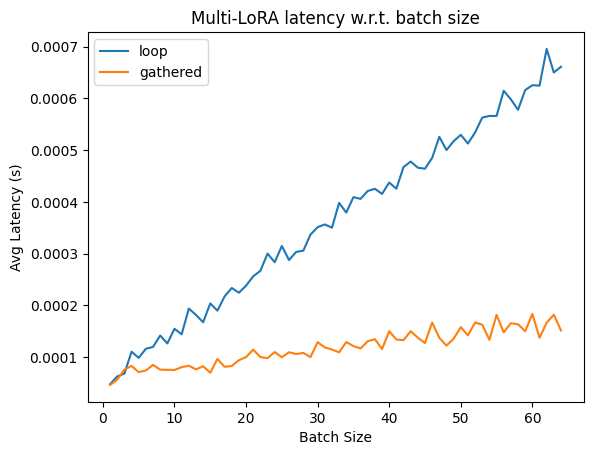

In [89]:
x = list(range(1, max_batch_size + 1))
plt.plot(x, avg_latencies_loop, label="loop")
plt.plot(x, avg_latencies_gathered, label="gathered")

plt.xlabel('Batch Size')
plt.ylabel('Avg Latency (s)')
plt.title('Multi-LoRA latency w.r.t. batch size')
plt.legend()

plt.show()